# **Build a Convolutional Neural Network (CNN) for Image Classification using CIFAR-10**

> ### **Introduction**:

Image classification is a fundamental task in computer vision that involves assigning labels to images based on their visual content. Convolutional Neural Networks (CNNs) are widely used for this task because they can automatically learn important features from images using convolution and pooling layers. In this assignment, a CNN model is developed to classify images from the CIFAR-10 dataset. The model includes convolutional, pooling, and fully connected layers, and its performance is evaluated using accuracy and loss curves

> ### **Overview**

* Develop a Convolutional Neural Network (CNN) for image classification.

* Use the CIFAR-10 dataset containing 10 image classes.

* Design the model with convolutional, pooling, and fully connected layers.

* Train the CNN using TensorFlow/Keras.

* Evaluate model performance using accuracy and loss curves.

## **Importing Required Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import cifar10


* Conv2D → convolution layer

* MaxPooling2D → pooling layer

* Dense → fully connected layer

### **Load CIFAR-10 Dataset**

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()




> **In this CIFAR-10 dataset**

* 50,000 training images

* 10,000 testing images

### **Data Preprocessing**

In [ ]:
# Normalize pixel values (0–255 → 0–1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)


> Normalization helps faster and stable training

### **Class Labels**

In [ ]:
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']


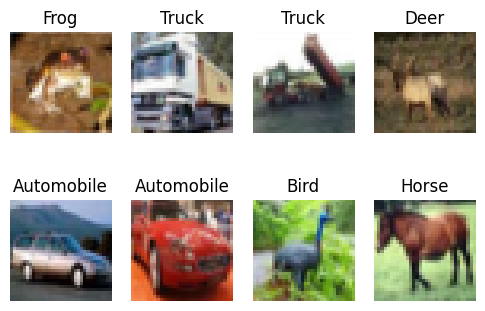

In [ ]:
plt.figure(figsize=(6,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(X_train[i], interpolation='nearest')
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()


## **Build CNN Model**

In [ ]:
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

# Convolution Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Convolution Layer 3
model.add(Conv2D(64, (3,3), activation='relu'))

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))


In [ ]:
model.summary() # Model Summary


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

**Explanation**:

* Convolution layers → feature extraction

* Pooling layers → dimensionality reduction

* Dense layers → classification

### **Compile the Model**

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])


### **Train the Model**

In [ ]:
history = model.fit(X_train, y_train,epochs=10,batch_size=64,validation_data=(X_test, y_test))


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 88ms/step - accuracy: 0.2688 - loss: 1.9512 - val_accuracy: 0.5116 - val_loss: 1.3499
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 86ms/step - accuracy: 0.4817 - loss: 1.4414 - val_accuracy: 0.5631 - val_loss: 1.2318
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 85ms/step - accuracy: 0.5449 - loss: 1.2791 - val_accuracy: 0.6073 - val_loss: 1.0995
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 86ms/step - accuracy: 0.5873 - loss: 1.1713 - val_accuracy: 0.6341 - val_loss: 1.0429
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 88ms/step - accuracy: 0.6172 - loss: 1.0941 - val_accuracy: 0.6485 - val_loss: 1.0021
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.6462 - loss: 1.0094 - val_accuracy: 0.6705 - val_loss: 0.9295
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 85ms/step - accuracy: 0.6651 - loss: 0.9615 - val_accuracy: 0.6845 - val_loss: 0.9010
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.6792 - loss: 0.9199 - 

### **Evaluate Model Performance**

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7150999903678894


### **Plot Training & Validation Accuracy**

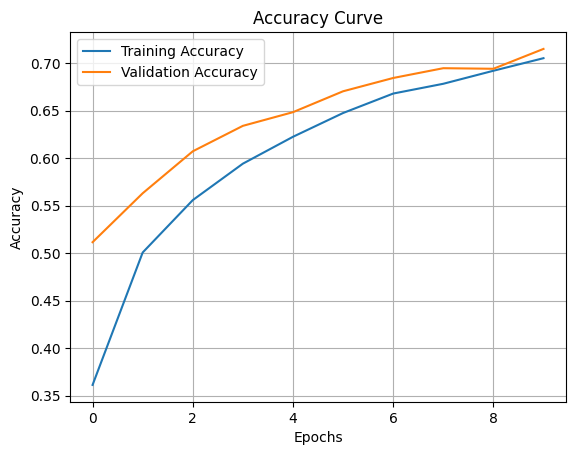

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()


### **Plot Training & Validation Loss**

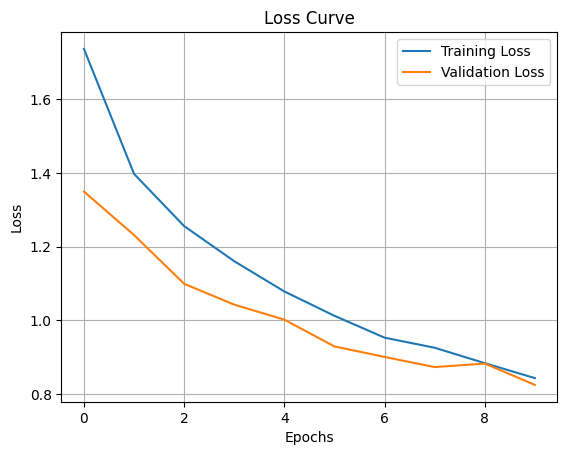

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


### **Prediction on Test Images**

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


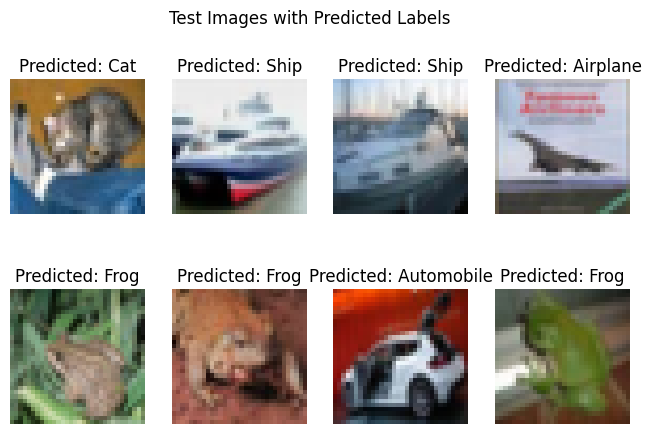

In [ ]:
# Class names for CIFAR-10 dataset
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

# Generate predictions for test images
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

# Plot test images with predicted labels
plt.figure(figsize=(8,5))

for i in range(8):
    plt.subplot(2,4,i+1)

    # Display test image
    plt.imshow(X_test[i], interpolation='nearest')

    # Show predicted class
    plt.title("Predicted: " + class_names[predicted_labels[i]])

    plt.axis('off')

plt.suptitle("Test Images with Predicted Labels")
plt.show()


 ## **Conclusion**

> In this approach, a Convolutional Neural Network (CNN) was developed to classify images from the CIFAR-10 dataset. The model consists of convolutional layers for feature extraction, pooling layers for dimensionality reduction, and fully connected layers for classification. The CNN achieved satisfactory accuracy on the test dataset. The accuracy and loss curves indicate effective learning and convergence of the model.